In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)
# Define the vocab and vocab_size

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

1500 pairs
['a', 'acqua', 'acque', 'aeroporti', 'aeroporto'] ['a', 'agua', 'aguas', 'aeropuertos', 'aeropuerto']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'ì', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 37
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[-8.7793e-01,  6.3379e-01, -1.0854e+00,  1.0807e+00, -1.5820e+00,
         -6.7991e-01,  6.8352e-01, -1.3590e+00, -2.3030e-01, -1.4724e-01,
         -3.3706e-01,  2.3864e-01,  1.2329e+00,  1.1520e+00,  6.6004e-01,
          1.1437e+00,  9.9569e-01,  6.3132e-01,  1.6042e+00, -6.9594e-01,
         -1.1707e-01, -1.8630e+00, -1.6485e+00, -3.8073e+00,  9.5018e-01,
         -7.0131e-01,  7.9756e-01,  1.3288e+00, -1.9197e+00, -3.1720e-01,
         -1.6166e-01,  1.7398e-02],
   

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[-2.3415e-01, -4.7032e-01, -6.4091e-01, -1.2130e-02, -4.5735e-01,
           3.7375e-01, -3.1616e-01, -2.9197e-01,  1.1200e+00,  2.2191e-01,
           1.7769e-01,  1.0536e+00, -7.3898e-01,  2.0782e-01,  1.0029e+00,
           3.4782e-01, -1.6554e-01,  2.5594e-02, -1.1708e-01,  2.5212e-01,
           1.2280e-01, -3.7561e-01, -1.0033e+00, -7.9495e-01, -6.5011e-01,
           2.0311e-01,  5.1458e-02,  5.6307e-01,  5.4519e-01, -1.4725e-01,
          -4.3872e-01, -1.0058e+00, -2.4742e-01, -2.8124e-01,  7.7615e-01,
          -1.3805e-01,  6.1184e-01],
         [-5.8404e-01, -4.2082e-01, -1.6486e+00,  1.9516e-01, -2.3362e-01,
          -4.2061e-01,  1.0210e-02, -2.2239e-01,  2.7056e-02, -3.9719e-01,
           7.7162e-01,  9.8878e-01, -2.0419e-01,  5.7047e-01,  7.6685e-02,
           5.0695e-01,  1.0502e+00,  5.6989e-01,  2.6920e-01, -7.7504e-01,
           9.6090e-02, -1.0872e-01, -7.3885e-01, -1.4388e-01, -2.3955e-01,
          -1.8547e-01,  3.6676e-01,  9.3469e-01,  1.1210e+00, -

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1184,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1221,
 'criterion': 0,
 'TOTAL': 91493}

# Fit the model

In [5]:

# define and train two models, a lighter and a heabier one
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo2 = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

# here weight_decya = 1e-2
trafo1_weight_decay = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)
trafo2_weight_decay = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)


print('trafo1')
print(trafo1.count_parameters_by_module())
print('trafo2')
print(trafo2.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo1')
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2')
trafo2.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo1_wd')
trafo1_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2_wd')
trafo2_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo1
{'embed': 592, 'pos_encoding': 0, 'encoder': 1286, 'decoder': 1468, 'exit_linear_projection': 629, 'criterion': 0, 'TOTAL': 3975}
trafo2
{'embed': 1184, 'pos_encoding': 0, 'encoder': 50944, 'decoder': 84864, 'exit_linear_projection': 1221, 'criterion': 0, 'TOTAL': 138213}
train trafo1
Epoch  0 / 500  loss =  3.9544339179992676  loss_eval =  3.9376418590545654
Epoch  100 / 500  loss =  1.6920936107635498  loss_eval =  1.7950818538665771
Epoch  200 / 500  loss =  1.2843962907791138  loss_eval =  1.4082709550857544
Epoch  300 / 500  loss =  1.1604896783828735  loss_eval =  1.3172260522842407
Epoch  400 / 500  loss =  1.0836526155471802  loss_eval =  1.268178105354309
train trafo2
Epoch  0 / 500  loss =  3.8927857875823975  loss_eval =  3.886021375656128
Epoch  100 / 500  loss =  0.26608335971832275  loss_eval =  0.8979948163032532
Epoch  200 / 500  loss =  0.0026732152327895164  loss_eval =  1.099121332168579
Epoch  300 / 500  loss =  0.0019582265522331  loss_eval =  1.146015524864

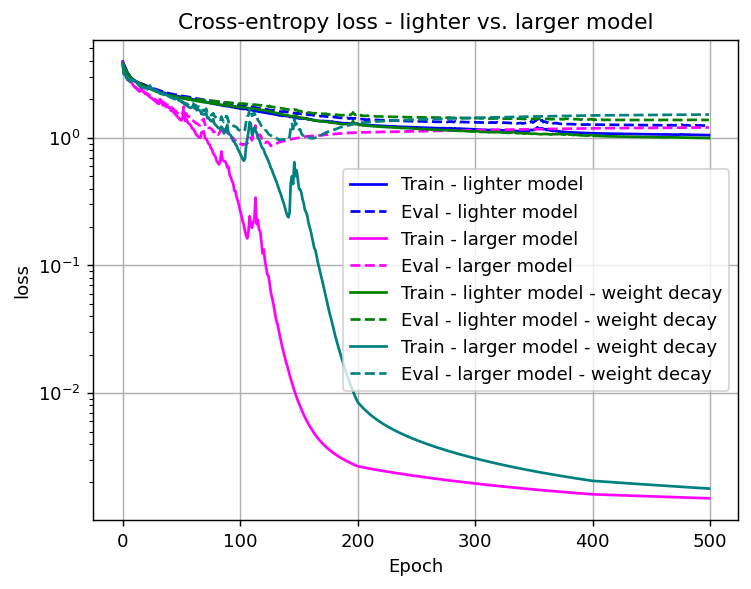

In [6]:
plt.figure(dpi = 130)
plt.title('Cross-entropy loss - lighter vs. larger model')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'blue', label = 'Train - lighter model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'blue', label = 'Eval - lighter model')
plt.semilogy(trafo2.epochs, trafo2.losses, color = 'magenta', label = 'Train - larger model')
plt.semilogy(trafo2.epochs, trafo2.losses_eval, '--', color = 'magenta', label = 'Eval - larger model')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses, color = 'green', label = 'Train - lighter model - weight decay')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses_eval, '--', color = 'green', label = 'Eval - lighter model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses, color = 'teal', label = 'Train - larger model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses_eval, '--', color = 'teal', label = 'Eval - larger model - weight decay')
plt.legend()
plt.show()

def translate_string(word, model):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = model.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [9]:

# intermediate size
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

print('trafo3')
print(trafo3.count_parameters_by_module())
print('train trafo3')
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo2_120epochs = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
print('train trafo2_120epochs')
trafo2_120epochs.fit_from_txt("it_es_cognates.txt", n_epochs=120)

trafo3
{'embed': 592, 'pos_encoding': 0, 'encoder': 3376, 'decoder': 4544, 'exit_linear_projection': 629, 'criterion': 0, 'TOTAL': 9141}
train trafo3
Epoch  0 / 500  loss =  3.737740993499756  loss_eval =  3.7395522594451904
Epoch  100 / 500  loss =  0.9156140685081482  loss_eval =  1.151203989982605
Epoch  200 / 500  loss =  0.4752891957759857  loss_eval =  0.975855827331543
Epoch  300 / 500  loss =  0.24213188886642456  loss_eval =  0.9963285326957703
Epoch  400 / 500  loss =  0.14399610459804535  loss_eval =  1.1550039052963257
train trafo2_120epochs
Epoch  0 / 120  loss =  3.7339401245117188  loss_eval =  3.727921962738037
Epoch  100 / 120  loss =  0.3600737154483795  loss_eval =  1.146469235420227


In [ ]:
italian_words = ["gatto", "nave", "croci", "croce", "dito", "stretta", "stretti", "stretto", "strette", "pensate", "lasagna", "passato"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]
expected_spanish_cognates_3 = [translate_string(word, trafo3) for word in italian_words]
expected_spanish_cognates_2_120ep = [translate_string(word, trafo2_120epochs) for word in italian_words]

print("Words in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output medium model':<20}| {'output larger model':<20} | {'output larger model 120 ep':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_3[k]:<20} | {expected_spanish_cognates_2_120ep[k]:<20}")

italian_words = ["lutti", "parato", "parata", "parati", "parate", "ottone", "castoro", "matti", "passata", "passate", "ossa"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]
expected_spanish_cognates_3 = [translate_string(word, trafo3) for word in italian_words]
expected_spanish_cognates_2_120ep = [translate_string(word, trafo2_120epochs) for word in italian_words]

print("Words not in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output medium model':<20}| {'output larger model':<20} | {'output larger model 120 ep':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_3[k]:<20}| {expected_spanish_cognates_2[k]:<20} | | {expected_spanish_cognates_2_120ep[k]:<20}")

Words in training dataset
Italian         | output light model   | output medium model | output larger model  | output larger model 120 ep
-----------------------------------------------------------
gatto           | gama                 | gato                 | gato                
nave            | nantados             | náeivas              | nave                
croci           | cueranos             | cruces               | cruces              
croce           | cuerado              | croce                | cruz                
dito            | dela                 | dedo                 | dedo                
stretta         | entrada              | estrecha             | estrecha            
stretti         | entras               | estrechos            | estrechos           
stretto         | entrado              | estrecho             | estrecho            
strette         | entras               | estrechas            | estrechas           
pensate         | pes               

# basically, overfitting
works fine on training dataset but not very well on random words. especially with large model. in some cases the lmodels give ok results for words not in training dataset (such as lutti - luchos). Note that the Spanish must does not have to exist in reality! It is only a hypothetical words obtained by applying the phonetical correspoendence between the two languages

same phenomenon if I change the number of layers n_layers. using weight decay with lambda = 1e-2 does not seem to make much of a difference

need bigger dataset

**regularization: try dropout and change weight decay parameter**